<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/practice/Student_TimeSeries_Forecasting_Example_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOAA Tides & Currents - 조석데이터 예측
- 과거 2년 학습 데이터를 바탕으로 예측모델을 만들고 2025년 구간데이터를 활용하여 모델을 검증한다.
- Seasonal Naive, AutoReg, SARIMA를 비교해 최종 모델을 선택한다.

**이름** : 안형석

**학번** : 2526527006


## 0) 데이터 설명
- **데이터 출처**: NOAA Tides & Currents API
- **관측소**: Boston (`8443970`)
- **변수**: 시간별 조위(`hourly_height`)
- **수집 연도**: 2023 ~ 2025
- **학습 구간**: 2023-01-01 ~ 2024-12-31
- **검증 구간**: 2025-01-01 ~ 2025-09-30
- **테스트 구간**: 2025-10-01 ~ 2025-12-31
- **단위**: meter, 기준면 `MLLW`

이 실습은 과거 2년 데이터를 학습에 사용하고, 이후 2025년 데이터를 validation 과 test로 나눠 성능을 평가한다.


## 실행 안내
1. 위에서 아래로 순서대로 실행한다.
2. NOAA API 호출이 있으므로 인터넷 연결이 필요하다.
3. 핵심 성능 결과는 `validation_results`, `test_results`, `summary_table`에서 확인한다.
4. 2025년 데이터가 validation 과 test에 어떻게 쓰였는지는 `split_table`에서 확인한다.
5. 추가 진단 결과는 `stationarity_report`, `stl_outlier_report`, `ljung_box_report`에서 확인한다.


In [ ]:
import importlib.util
import subprocess
import sys

required = {
    'requests': 'requests',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'statsmodels': 'statsmodels',
    'sklearn': 'scikit-learn',
}
missing = [pip_name for module_name, pip_name in required.items() if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox


## 1) API 설정

In [ ]:
# 실험 구간과 모델 후보를 한 곳에서 관리
BASE_URL = 'https://api.tidesandcurrents.noaa.gov/api/prod/datagetter'

STATION = {
    'id': '8443970',
    'name': 'Boston',
}

DATA_YEARS = [2023, 2024, 2025]
TRAIN_START = '2023-01-01 00:00'
TRAIN_END = '2024-12-31 23:00'
VALID_START = '2025-01-01 00:00'
VALID_END = '2025-09-30 23:00'
TEST_START = '2025-10-01 00:00'
TEST_END = '2025-12-31 23:00'

PRODUCT = 'hourly_height'
DATUM = 'MLLW'
TIME_ZONE = 'gmt'
UNITS = 'metric'
FMT = 'json'

SEASONAL_PERIOD = 12
AUTOREG_LAG_CANDIDATES = [24, 48, 72, 96, 168, 336]
SARIMA_ORDER = (2, 0, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 0, SEASONAL_PERIOD)
ZOOM_DAYS = 21
PACF_LAGS = 60

STATION

{'id': '8443970', 'name': 'Boston'}

In [ ]:
# NOAA hourly 데이터는 연도 단위로 받아서 합침
def fetch_noaa_hourly_year(station_id: str,
                           year: int,
                           product: str = PRODUCT,
                           datum: str = DATUM,
                           time_zone: str = TIME_ZONE,
                           units: str = UNITS,
                           fmt: str = FMT) -> tuple[pd.DataFrame, dict]:
    params = {
        'product': product,
        'application': 'TimeSeriesAnalysis',
        'begin_date': f'{year}0101',
        'end_date': f'{year}1231',
        'station': station_id,
        'datum': datum,
        'time_zone': time_zone,
        'units': units,
        'format': fmt,
    }

    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    if 'data' not in js:
        raise ValueError(f'API 응답에 data가 없습니다: {js}')

    df = pd.DataFrame(js['data'])
    df['t'] = pd.to_datetime(df['t'], errors='coerce')
    df['water_level_m'] = pd.to_numeric(df['v'], errors='coerce').astype('float32')
    df['sigma_m'] = pd.to_numeric(df['s'], errors='coerce').astype('float32')
    df['year'] = year
    df = df[['t', 'water_level_m', 'sigma_m', 'year']].dropna(subset=['t'])
    return df, js.get('metadata', {})


def expected_hourly_rows(year: int) -> int:
    start = pd.Timestamp(f'{year}-01-01 00:00')
    end = pd.Timestamp(f'{year}-12-31 23:00')
    return len(pd.date_range(start, end, freq='h'))

## 2) 데이터 수집 및 구조 점검

In [ ]:
# 연도별 응답을 모아 하나의 원본 테이블로 정리
frames = []
meta = {}
for year in DATA_YEARS:
    df_year, meta = fetch_noaa_hourly_year(STATION['id'], year)
    frames.append(df_year)

raw_df = pd.concat(frames, ignore_index=True)
raw_df = raw_df.sort_values('t').reset_index(drop=True)

print('station :', meta.get('name'), meta.get('id'))
print('lat/lon :', meta.get('lat'), meta.get('lon'))
print('rows    :', len(raw_df))
print('period  :', raw_df['t'].min(), '->', raw_df['t'].max())

raw_df.head()

station : Boston 8443970
lat/lon : 42.3539 -71.0503
rows    : 26304
period  : 2023-01-01 00:00:00 -> 2025-12-31 23:00:00


,t,water_level_m,sigma_m,year
0,2023-01-01 00:00:00,2.801,0.010,2023
1,2023-01-01 01:00:00,2.488,0.014,2023
2,2023-01-01 02:00:00,1.967,0.018,2023
3,2023-01-01 03:00:00,1.365,0.033,2023
4,2023-01-01 04:00:00,0.781,0.014,2023


In [ ]:
# 연도별 수집 누락이 없는지 먼저 확인
coverage_records = []
for year in DATA_YEARS:
    year_df = raw_df[raw_df['year'] == year].copy()
    observed_rows = len(year_df)
    non_missing_rows = int(year_df['water_level_m'].notna().sum())
    coverage_records.append({
        'Year': year,
        'ExpectedRows': expected_hourly_rows(year),
        'ObservedRows': observed_rows,
        'NonMissingRows': non_missing_rows,
        'MissingRows': expected_hourly_rows(year) - non_missing_rows,
    })

yearly_coverage = pd.DataFrame(coverage_records)
yearly_coverage

,Year,ExpectedRows,ObservedRows,NonMissingRows,MissingRows
0,2023,8760,8760,8760,0
1,2024,8784,8784,8784,0
2,2025,8760,8760,8760,0


In [ ]:
# 전체 시간축에 다시 맞춰 결측 확인
df = raw_df[['t', 'water_level_m', 'sigma_m']].dropna(subset=['t']).set_index('t').sort_index()
full_index = pd.date_range(df.index.min(), df.index.max(), freq='h')
y_raw = df['water_level_m'].reindex(full_index)

print('expected hourly rows:', len(full_index))
print('observed rows       :', len(df))
print('missing values      :', int(y_raw.isna().sum()))

expected hourly rows: 26304
observed rows       : 26304
missing values      : 0


## 3) 데이터 정합성 검증

In [ ]:
# 중복, 간격, 결측 길이를 한 번에 점검
expected_delta = pd.Timedelta(hours=1)
intervals = df.index.to_series().diff().dropna()
missing_mask = y_raw.isna()

if missing_mask.any():
    groups = (missing_mask != missing_mask.shift()).cumsum()
    max_gap_steps = int(missing_mask.groupby(groups).sum().max())
else:
    max_gap_steps = 0

validation_report = pd.DataFrame({
    'value': [
        int(df.index.duplicated().sum()),
        int((intervals != expected_delta).sum()),
        int(missing_mask.sum()),
        round(float(missing_mask.mean() * 100), 3),
        max_gap_steps,
        round(float(max_gap_steps), 2),
    ]
}, index=[
    'duplicate_index_count',
    'non_hourly_interval_count',
    'missing_count',
    'missing_ratio_pct',
    'max_missing_gap_steps',
    'max_missing_gap_hours',
])

validation_report

,value
duplicate_index_count,0.0
non_hourly_interval_count,0.0
missing_count,0.0
missing_ratio_pct,0.0
max_missing_gap_steps,0.0
max_missing_gap_hours,0.0


In [ ]:
y = y_raw.interpolate(limit=6, limit_direction='both').astype('float32')

if y.isna().any():
    raise ValueError('보간 후에도 결측이 남아 있어 학습을 진행할 수 없습니다.')

print('final series length:', len(y))
print('remaining missing  :', int(y.isna().sum()))

final series length: 26304
remaining missing  : 0


## 4) 시각화

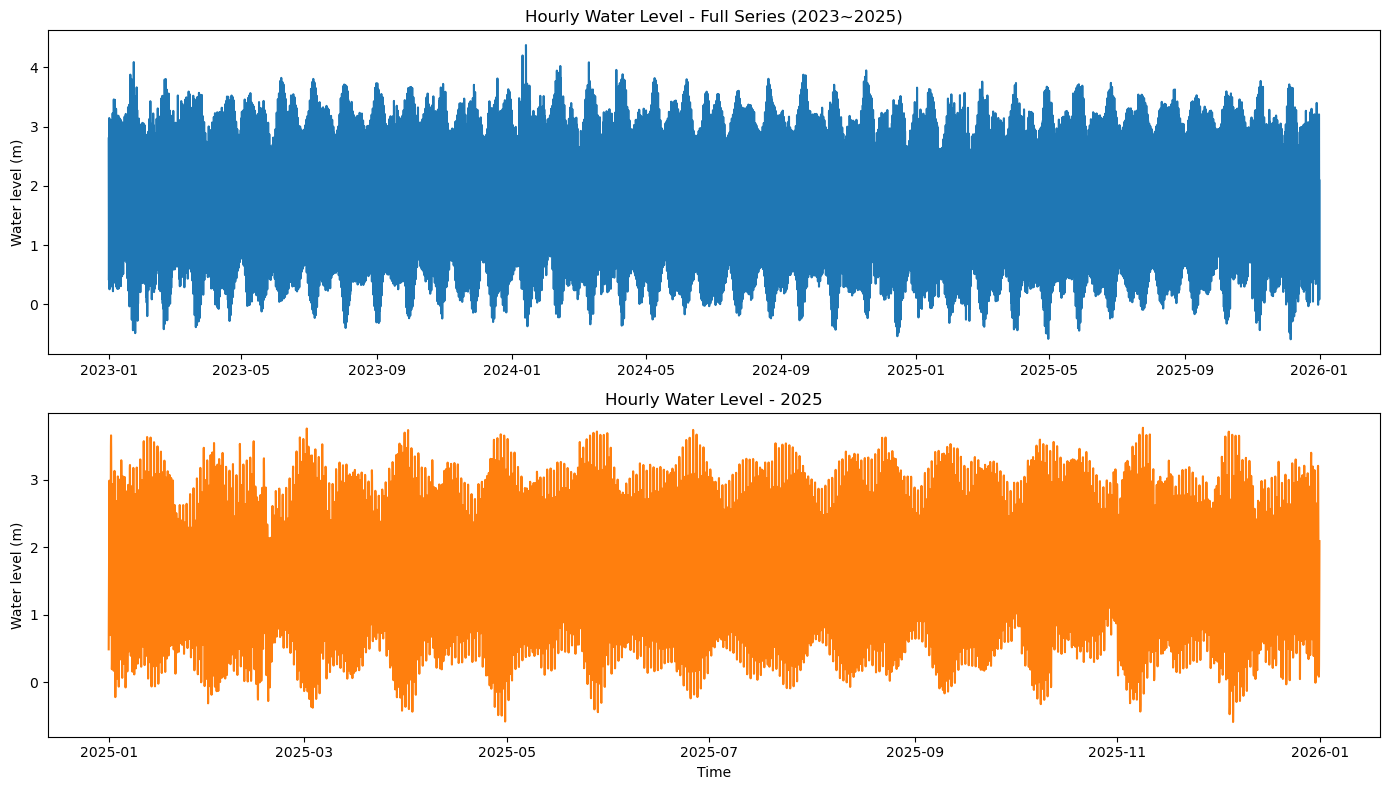

In [ ]:
# 전체 구간과 2025년 구간을 나눠 패턴을 확인
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(y.index, y, color='tab:blue')
axes[0].set_title('Hourly Water Level - Full Series (2023~2025)')
axes[0].set_ylabel('Water level (m)')

focus_2025 = y.loc['2025-01-01':]
axes[1].plot(focus_2025.index, focus_2025, color='tab:orange')
axes[1].set_title('Hourly Water Level - 2025')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Water level (m)')

plt.tight_layout()
plt.show()
plt.close('all')

In [ ]:
monthly_summary = focus_2025.resample('MS').agg(['mean', 'std', 'min', 'max'])
monthly_summary

,mean,std,min,max
2025-01-01,1.657587,0.991191,-0.316,3.659
2025-02-01,1.620534,0.997468,-0.282,3.629
2025-03-01,1.674251,1.031220,-0.425,3.761
2025-04-01,1.686594,1.017059,-0.586,3.738
2025-05-01,1.764673,1.014481,-0.447,3.716
2025-06-01,1.731692,0.990245,-0.242,3.740
2025-07-01,1.732251,0.973620,-0.094,3.542
2025-08-01,1.752563,0.967901,-0.073,3.628
2025-09-01,1.756836,0.970682,-0.168,3.530
2025-10-01,1.815153,0.967115,-0.328,3.596


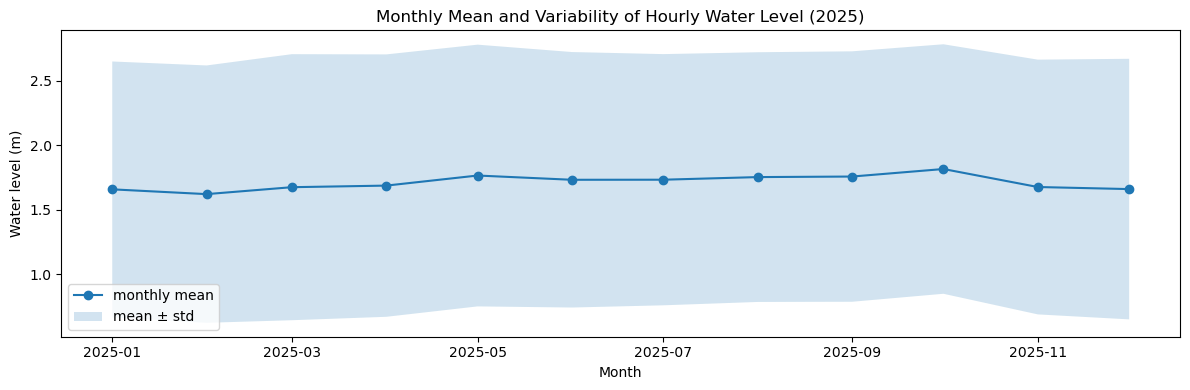

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_summary.index, monthly_summary['mean'], marker='o', label='monthly mean')
plt.fill_between(
    monthly_summary.index,
    monthly_summary['mean'] - monthly_summary['std'],
    monthly_summary['mean'] + monthly_summary['std'],
    alpha=0.2,
    label='mean ± std',
)
plt.title('Monthly Mean and Variability of Hourly Water Level (2025)')
plt.xlabel('Month')
plt.ylabel('Water level (m)')
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all')

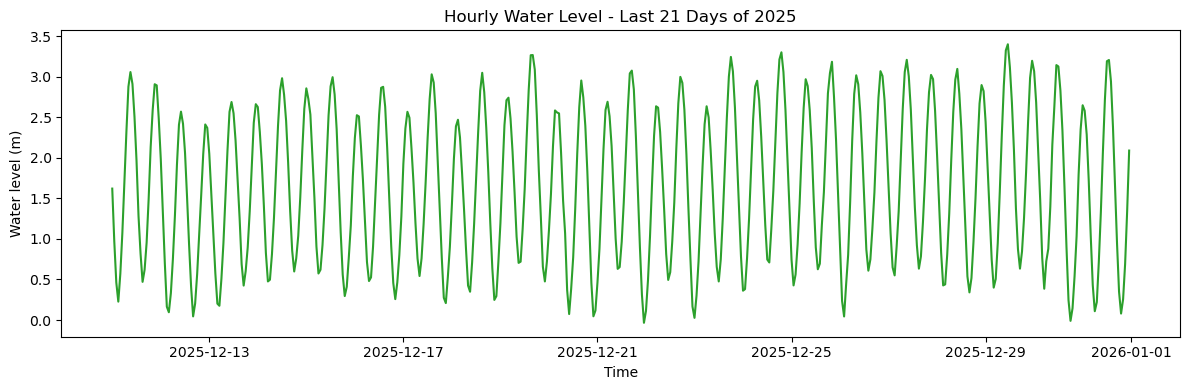

In [ ]:
# 최근 구간 확인
recent = focus_2025.last(f'{ZOOM_DAYS}D')
plt.figure(figsize=(12, 4))
plt.plot(recent.index, recent, color='tab:green')
plt.title(f'Hourly Water Level - Last {ZOOM_DAYS} Days of 2025')
plt.xlabel('Time')
plt.ylabel('Water level (m)')
plt.tight_layout()
plt.show()
plt.close('all')

## 5) STL / ACF / PACF 진단

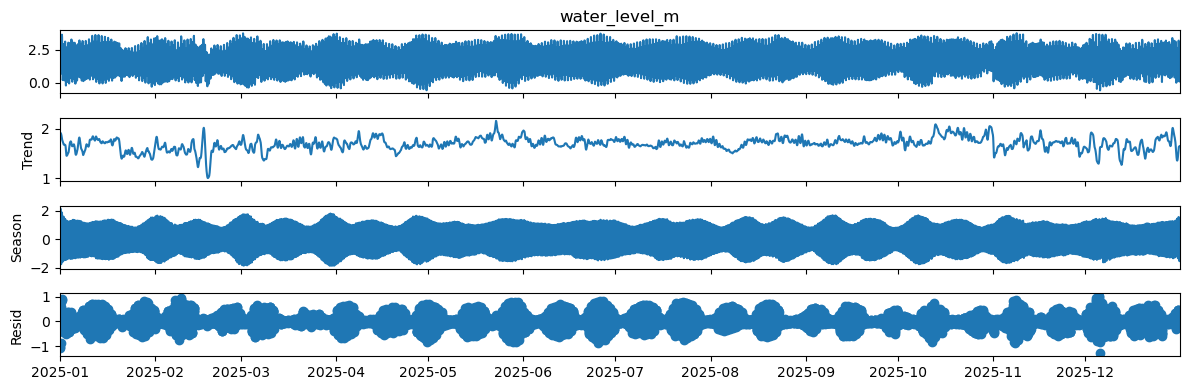

In [ ]:
# STL로 추세, 계절, 잔차를 분리
stl_result = STL(focus_2025, period=SEASONAL_PERIOD, robust=True).fit()
stl_result.plot()
plt.tight_layout()
plt.show()
plt.close('all')

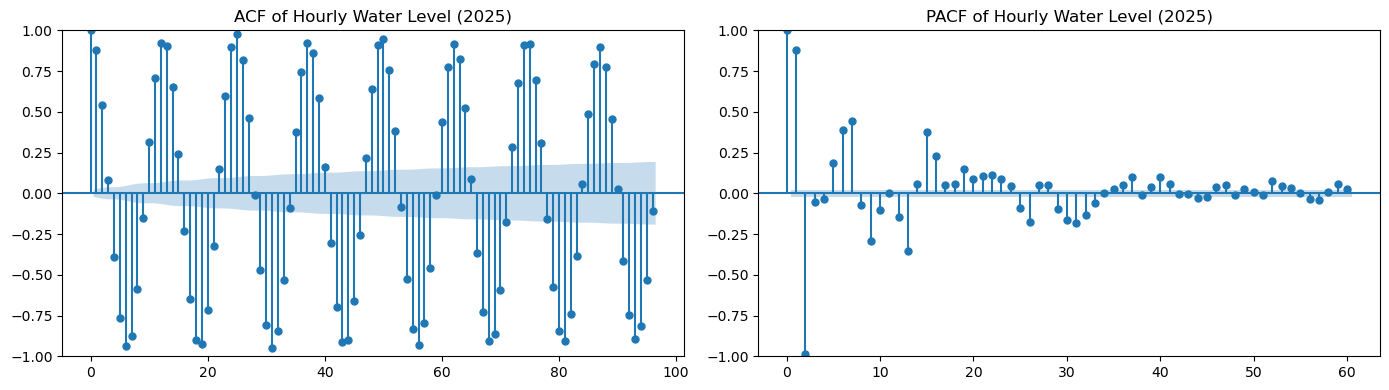

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(focus_2025, lags=SEASONAL_PERIOD * 8, ax=axes[0])
plot_pacf(focus_2025, lags=PACF_LAGS, ax=axes[1], method='ywm')
axes[0].set_title('ACF of Hourly Water Level (2025)')
axes[1].set_title('PACF of Hourly Water Level (2025)')
plt.tight_layout()
plt.show()
plt.close('all')

## 5-1) 추가 진단: 정상성 / 이상치
강의 실습에서 다룬 `ADF/KPSS`, `STL+IQR` 점검을 NOAA 데이터에도 적용한다.
이상치 진단은 데이터를 삭제하기 위한 절차가 아니라, 변동이 큰 구간과 잔차 분포를 확인하기 위한 진단이다.


In [ ]:
# 학습 구간의 원시계열과 1차 차분에 대해 정상성을 비교
def adf_kpss_summary(series: pd.Series, label: str, regression: str = 'c') -> dict:
    clean = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(clean, autolag='AIC', regression=regression)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, _, _ = kpss(clean, regression=regression, nlags='auto')
    return {
        'Series': label,
        'ADF p-value': adf_p,
        'KPSS p-value': kpss_p,
        'ADF says stationary': adf_p < 0.05,
        'KPSS says stationary': kpss_p >= 0.05,
    }

train_series = y.loc[pd.Timestamp(TRAIN_START):pd.Timestamp(TRAIN_END)]
train_diff = train_series.diff().dropna()
stationarity_report = pd.DataFrame([
    adf_kpss_summary(train_series, 'Train level'),
    adf_kpss_summary(train_diff, 'Train 1st diff'),
])

stationarity_report


,Series,ADF p-value,KPSS p-value,ADF says stationary,KPSS says stationary
0,Train level,4.129269e-27,0.048852,True,False
1,Train 1st diff,0.000000e+00,0.100000,True,True


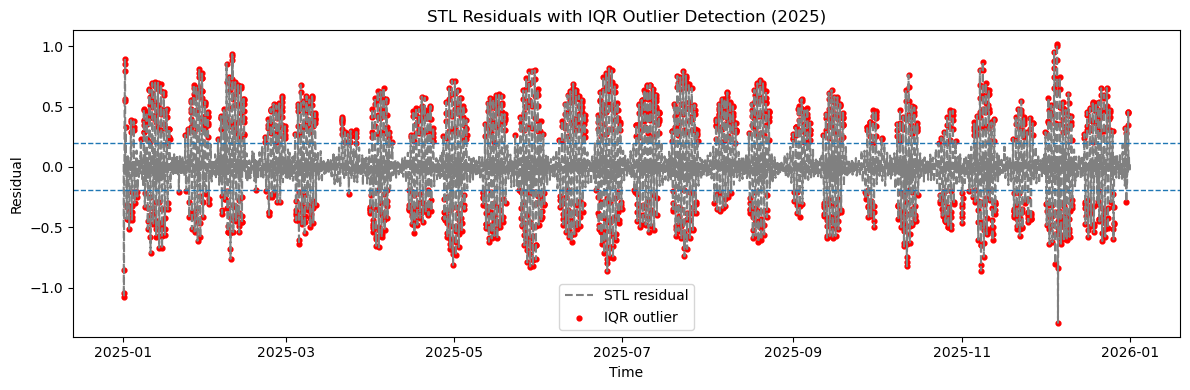

,ResidualCount,OutlierCount,OutlierRatioPct,LowerBound,UpperBound
0,8760,1849,21.107,-0.187,0.1974


In [ ]:
# STL 잔차에서 IQR 기준으로 변동이 큰 시점을 표시
stl_resid = stl_result.resid.dropna()
q1 = stl_resid.quantile(0.25)
q3 = stl_resid.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
stl_outliers = (stl_resid < lower) | (stl_resid > upper)

stl_outlier_report = pd.DataFrame([
    {
        'ResidualCount': len(stl_resid),
        'OutlierCount': int(stl_outliers.sum()),
        'OutlierRatioPct': round(float(stl_outliers.mean() * 100), 3),
        'LowerBound': round(float(lower), 4),
        'UpperBound': round(float(upper), 4),
    }
])

plt.figure(figsize=(12, 4))
plt.plot(stl_resid.index, stl_resid, color='gray', linestyle='--', label='STL residual')
plt.scatter(stl_resid.index[stl_outliers], stl_resid[stl_outliers], color='red', s=12, label='IQR outlier')
plt.axhline(lower, color='tab:blue', linestyle='--', linewidth=1)
plt.axhline(upper, color='tab:blue', linestyle='--', linewidth=1)
plt.title('STL Residuals with IQR Outlier Detection (2025)')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all')

stl_outlier_report

## 6) Train / Validation / Test 분리

In [ ]:
# 미래 정보가 섞이지 않도록 시간 순서대로 분할
train = y.loc[pd.Timestamp(TRAIN_START):pd.Timestamp(TRAIN_END)]
valid = y.loc[pd.Timestamp(VALID_START):pd.Timestamp(VALID_END)]
test = y.loc[pd.Timestamp(TEST_START):pd.Timestamp(TEST_END)]

split_table = pd.DataFrame([
    {'Split': 'Train', 'Start': train.index.min(), 'End': train.index.max(), 'Rows': len(train)},
    {'Split': 'Validation', 'Start': valid.index.min(), 'End': valid.index.max(), 'Rows': len(valid)},
    {'Split': 'Test', 'Start': test.index.min(), 'End': test.index.max(), 'Rows': len(test)},
])

split_table

,Split,Start,End,Rows
0,Train,2023-01-01,2024-12-31 23:00:00,17544
1,Validation,2025-01-01,2025-09-30 23:00:00,6552
2,Test,2025-10-01,2025-12-31 23:00:00,2208


In [ ]:
# 평가 지표와 계절 naive 기준선을 함수로 고정
def eval_forecast(y_true: pd.Series, y_pred: pd.Series) -> dict:
    return {
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }


def seasonal_naive_forecast(full_series: pd.Series,
                            target_index: pd.DatetimeIndex,
                            seasonal_period: int) -> pd.Series:
    pred = pd.Series(index=target_index, dtype='float64')
    for t in target_index:
        lag_t = t - pd.Timedelta(hours=seasonal_period)
        pred.loc[t] = full_series.loc[lag_t]
    return pred

## 7) Validation으로 모델 선택

In [ ]:
# validation 구간에서 가장 나은 모델 확인
validation_records = []
validation_predictions = {}

valid_naive = seasonal_naive_forecast(y, valid.index, SEASONAL_PERIOD)
validation_predictions['Seasonal Naive'] = valid_naive
validation_records.append({
    'Model': 'Seasonal Naive',
    'Config': f'lag={SEASONAL_PERIOD}',
    **eval_forecast(valid, valid_naive),
})

for lag in AUTOREG_LAG_CANDIDATES:
    model = AutoReg(train, lags=lag, old_names=False, seasonal=False).fit()
    pred = model.predict(start=len(train), end=len(train) + len(valid) - 1, dynamic=False)
    pred.index = valid.index
    validation_predictions[f'AutoReg({lag})'] = pred
    validation_records.append({
        'Model': 'AutoReg',
        'Config': f'lags={lag}',
        **eval_forecast(valid, pred),
    })

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sarima_valid_model = SARIMAX(
        train,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)

sarima_valid_pred = sarima_valid_model.forecast(len(valid))
sarima_valid_pred.index = valid.index
validation_predictions['SARIMA'] = sarima_valid_pred
validation_records.append({
    'Model': 'SARIMA',
    'Config': f'{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}',
    **eval_forecast(valid, sarima_valid_pred),
})

validation_results = pd.DataFrame(validation_records).sort_values('RMSE').reset_index(drop=True)
validation_results

,Model,Config,RMSE,MAE
0,AutoReg,lags=336,0.251018,0.200874
1,Seasonal Naive,lag=12,0.383493,0.314914
2,AutoReg,lags=168,0.407924,0.330307
3,AutoReg,lags=24,0.634548,0.523569
4,AutoReg,lags=96,0.927112,0.780967
5,AutoReg,lags=48,0.951399,0.811778
6,AutoReg,lags=72,0.985318,0.838356
7,SARIMA,"(2, 0, 1)x(1, 0, 0, 12)",1.917470,1.645650


In [ ]:
# AutoReg 최적 lag와 validation 최고 모델을 따로 확인
best_autoreg_row = validation_results[validation_results['Model'] == 'AutoReg'].iloc[0]
selected_autoreg_lag = int(best_autoreg_row['Config'].split('=')[1])
selected_model_name = validation_results.iloc[0]['Model']
selected_model_config = validation_results.iloc[0]['Config']

print('selected autoreg lag :', selected_autoreg_lag)
print('best validation model:', selected_model_name, selected_model_config)

selected autoreg lag : 336
best validation model: AutoReg lags=336


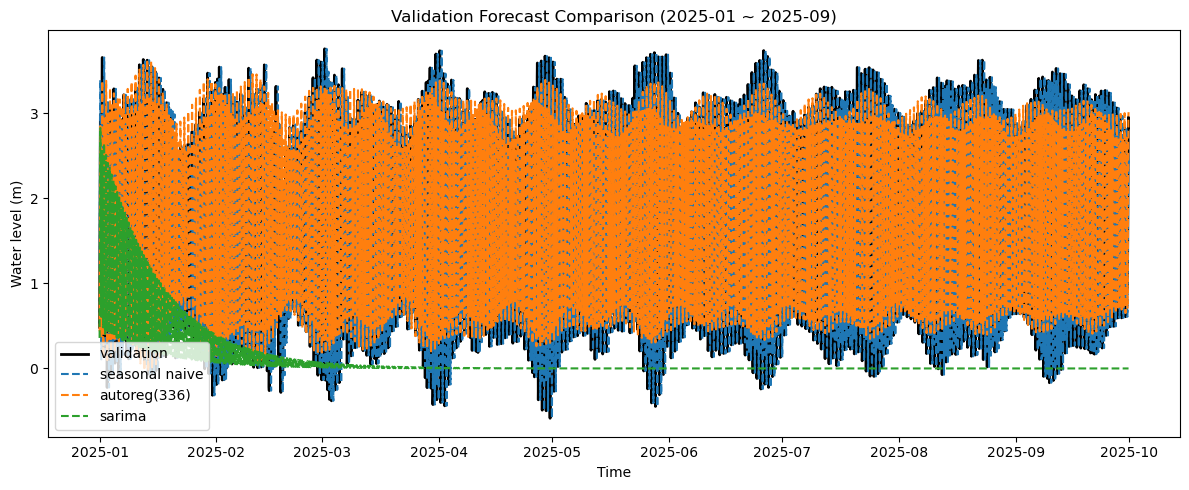

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(valid.index, valid, label='validation', color='black', linewidth=2)
plt.plot(valid_naive.index, valid_naive, label='seasonal naive', linestyle='--')
plt.plot(validation_predictions[f'AutoReg({selected_autoreg_lag})'].index,
         validation_predictions[f'AutoReg({selected_autoreg_lag})'],
         label=f'autoreg({selected_autoreg_lag})', linestyle='--')
plt.plot(sarima_valid_pred.index, sarima_valid_pred, label='sarima', linestyle='--')
plt.title('Validation Forecast Comparison (2025-01 ~ 2025-09)')
plt.xlabel('Time')
plt.ylabel('Water level (m)')
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all')

## 8) Test 구간 최종 평가

In [ ]:
# 선택된 설정으로 train+valid에 다시 학습한 뒤 test를 평가
train_valid = y.loc[pd.Timestamp(TRAIN_START):pd.Timestamp(VALID_END)]

test_naive = seasonal_naive_forecast(y, test.index, SEASONAL_PERIOD)

autoreg_final_model = AutoReg(train_valid, lags=selected_autoreg_lag, old_names=False, seasonal=False).fit()
test_autoreg = autoreg_final_model.predict(start=len(train_valid), end=len(train_valid) + len(test) - 1, dynamic=False)
test_autoreg.index = test.index

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sarima_final_model = SARIMAX(
        train_valid,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)

test_sarima = sarima_final_model.forecast(len(test))
test_sarima.index = test.index

test_results = pd.DataFrame([
    {'Model': 'Seasonal Naive', 'Config': f'lag={SEASONAL_PERIOD}', **eval_forecast(test, test_naive)},
    {'Model': 'AutoReg', 'Config': f'lags={selected_autoreg_lag}', **eval_forecast(test, test_autoreg)},
    {'Model': 'SARIMA', 'Config': f'{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}', **eval_forecast(test, test_sarima)},
]).sort_values('RMSE').reset_index(drop=True)

test_results

,Model,Config,RMSE,MAE
0,AutoReg,lags=336,0.237754,0.187787
1,Seasonal Naive,lag=12,0.387277,0.316415
2,SARIMA,"(2, 0, 1)x(1, 0, 0, 12)",1.779110,1.502631


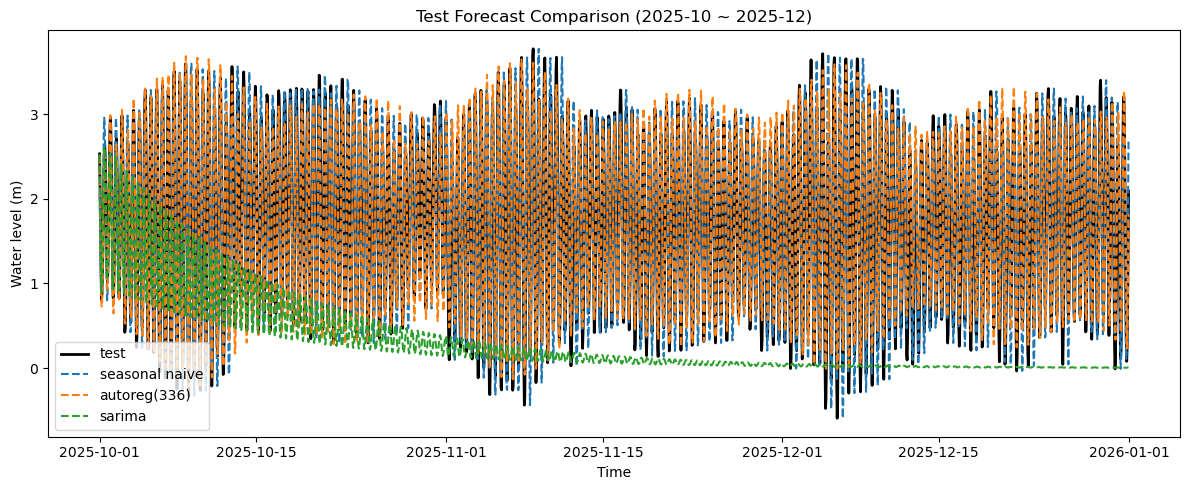

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='test', color='black', linewidth=2)
plt.plot(test_naive.index, test_naive, label='seasonal naive', linestyle='--')
plt.plot(test_autoreg.index, test_autoreg, label=f'autoreg({selected_autoreg_lag})', linestyle='--')
plt.plot(test_sarima.index, test_sarima, label='sarima', linestyle='--')
plt.title('Test Forecast Comparison (2025-10 ~ 2025-12)')
plt.xlabel('Time')
plt.ylabel('Water level (m)')
plt.legend()
plt.tight_layout()
plt.show()
plt.close('all')

## 8-1) 추가 진단: Ljung-Box 잔차 검정
강의 실습의 Ljung–Box 검정을 사용해 최종 AutoReg 예측 오차에 남은 자기상관이 있는지 확인한다.

In [ ]:
# 최종 AutoReg 잔차에 자기상관이 남는지 검정
selected_residual = test - test_autoreg
ljung_box_report = acorr_ljungbox(selected_residual, lags=[12, 24, 36], return_df=True)
ljung_box_report = ljung_box_report.rename(columns={'lb_stat': 'LB stat', 'lb_pvalue': 'p-value'})
ljung_box_report['decision'] = np.where(
    ljung_box_report['p-value'] < 0.05,
    'Reject H0: autocorrelation remains',
    'Fail to reject H0: no strong autocorrelation evidence',
)
ljung_box_report

,LB stat,p-value,decision
12,5853.330660,0.0,Reject H0: autocorrelation remains
24,9454.412221,0.0,Reject H0: autocorrelation remains
36,12716.060210,0.0,Reject H0: autocorrelation remains


## 9) 요약

In [ ]:
# 핵심 결과를 표
best_test_row = test_results.iloc[0]
summary_table = pd.DataFrame([
    {'항목': '데이터', '내용': 'NOAA Boston(8443970) 시간별 조위, 2023~2025'},
    {'항목': '학습 구간', '내용': '2023-01-01 ~ 2024-12-31 (2년)'},
    {'항목': 'Validation 구간', '내용': '2025-01-01 ~ 2025-09-30'},
    {'항목': 'Test 구간', '내용': '2025-10-01 ~ 2025-12-31'},
    {'항목': '정합성 검증', '내용': f"중복 {int(validation_report.loc['duplicate_index_count', 'value'])}건, 결측 {int(validation_report.loc['missing_count', 'value'])}건"},
    {'항목': 'Validation 최고 모델', '내용': f'{selected_model_name} ({selected_model_config})'},
    {'항목': '정상성 진단', '내용': 'Level은 KPSS 기준 비정상 가능성, 1차 차분은 정상성 확인'},
    {'항목': 'STL 잔차 이상치 진단', '내용': f"{int(stl_outlier_report.loc[0, 'OutlierCount'])}건 ({stl_outlier_report.loc[0, 'OutlierRatioPct']}%)"},
    {'항목': 'Ljung-Box(잔차)', '내용': ljung_box_report['decision'].iloc[-1]},
    {'항목': 'Test 최고 모델', '내용': f"{best_test_row['Model']} ({best_test_row['Config']})"},
    {'항목': 'Test RMSE', '내용': round(float(best_test_row['RMSE']), 4)},
    {'항목': 'Test MAE', '내용': round(float(best_test_row['MAE']), 4)},
])

summary_table


,항목,내용
0,데이터,"NOAA Boston(8443970) 시간별 조위, 2023~2025"
1,학습 구간,2023-01-01 ~ 2024-12-31 (2년)
2,Validation 구간,2025-01-01 ~ 2025-09-30
3,Test 구간,2025-10-01 ~ 2025-12-31
4,정합성 검증,"중복 0건, 결측 0건"
5,Validation 최고 모델,AutoReg (lags=336)
6,정상성 진단,"Level은 KPSS 기준 비정상 가능성, 1차 차분은 정상성 확인"
7,STL 잔차 이상치 진단,1849건 (21.107%)
8,Ljung-Box(잔차),Reject H0: autocorrelation remains
9,Test 최고 모델,AutoReg (lags=336)


### 결론
- `2023~2024` 2년 데이터를 학습에 사용했다.
- `2025-01-01 ~ 2025-09-30`은 validation 구간, `2025-10-01 ~ 2025-12-31`은 test 구간으로 사용했다.
- 강의 실습 기법을 반영해 `ADF/KPSS 정상성 점검`, `STL+IQR 잔차 이상치 진단`, `Ljung–Box 잔차 진단`을 추가했다.
- 진단 결과, 원시 level은 KPSS 기준으로 완전한 정상성으로 보기 어렵고 1차 차분에서는 정상성이 확인됐다.
- 최종 `AutoReg(lags=336)`는 test 구간에서 가장 낮은 오차를 보였지만, Ljung–Box 결과 잔차 자기상관이 남아 있어 추가 개선 여지는 있다.
